In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
import os

USER_PATH = '~/OneDrive - PNNL'
DATA_PATH = 'E-COMP - mocodo'

path = os.path.join(os.path.expanduser(USER_PATH), DATA_PATH)

os.listdir(path)

['MoCoDo formulation.docx', 'design_data.csv', 'control_data.csv']

In [108]:
df_design = pd.read_csv(os.path.join(path, 'design_solution.csv'), index_col=0)
df_design

,Cable Capacity(MW),Battery Rated Power(MW),Cable Material Cost($M),Battery Cost($M),Day-Ahead Revenue ($k),Real-Time Revenue ($k),Reserve Revenue ($k)
CCD18_3_cotwdpge,1991.00,54.3,200.492357,48.276121,1087.483919,19.086819,1.589130
CCD18_3_johnday,2585.00,70.5,356.845317,62.678942,1360.736564,33.640009,2.047136
CCD18_3_mossland,1980.00,54.0,406.362346,48.009402,960.069036,20.172016,1.518664
CCD18_3_tesla,2904.00,79.2,544.461696,70.413790,1482.514296,39.053810,2.284544
CCD18_3_wcascade,1650.00,45.0,279.351613,40.007835,914.052669,19.100964,1.299891
CCD22_3_cotwdpge,1991.01,90.5,200.493364,80.460201,2534.618126,13.567029,2.867339
CCD22_3_johnday,2585.00,117.5,356.845317,104.464902,3006.607974,23.248420,3.513141
CCD22_3_mossland,1980.00,90.0,406.362346,80.015670,2106.896264,10.547262,2.667417
CCD22_3_tesla,2904.00,132.0,544.461696,117.356316,3375.888794,7.885756,4.122612
CCD22_3_wcascade,1650.00,75.0,279.351613,66.679725,2099.216058,20.678240,2.290448


In [126]:
from importlib import reload
import tradeoff_lattice as tl

/Users/aren438/anaconda3/envs/moods/lib/python3.11/site-packages/umap/umap_.py:2433: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


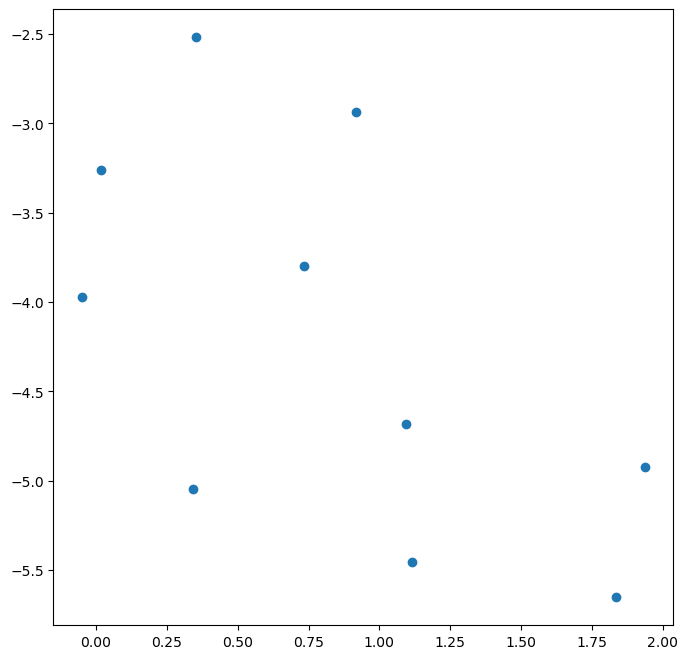

In [127]:
from umap import UMAP

xy = UMAP().fit_transform(df)

plt.scatter(*xy.T)

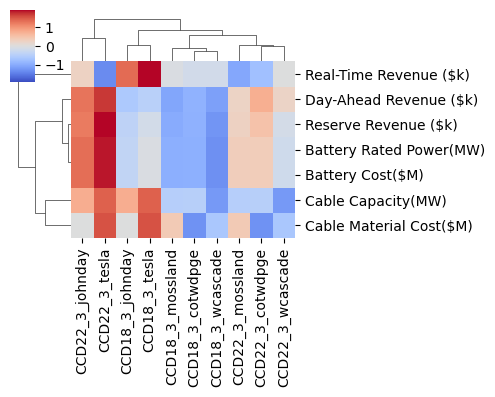

In [177]:
import seaborn as sns;

vmax = coef.abs().max().max()

sns.clustermap(coef.T, cmap='coolwarm', vmin=-vmax, vmax=vmax, figsize=(5, 4))

(68.848315, 249.13468500000002, -50.04, 734.04)

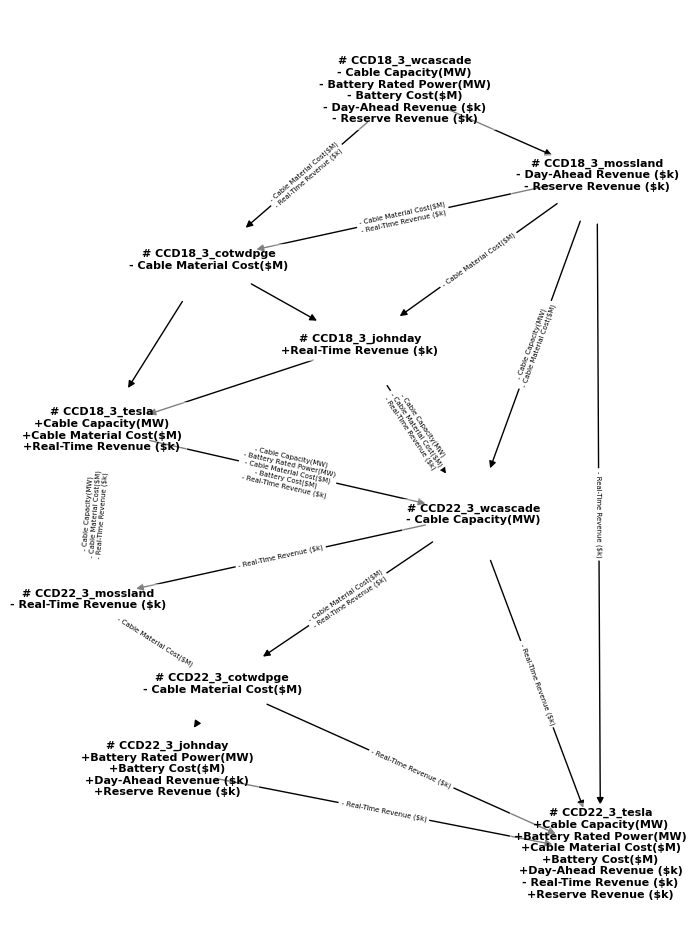

In [171]:
reload(tl)

plt.figure(figsize=(8, 12))
G, coef = tl.get_tradeoff_lattice_direct(df_design, xy)
tl.draw_tradeoff_lattice(
    G,
    coef=coef,
    by='Reserve Revenue ($k)',
    node_size=5000,
    edge_labels_kwargs=dict(font_size=5),
    node_labels_kwargs=dict(fontsize=8, fontweight='bold')
)

plt.axis('off')

In [178]:
df_control = pd.read_csv(os.path.join(path, 'control_data.csv'))\
    .set_index(['config', 'sim', 'time'])
df_control

ChS      DisS  ...         pWDS          pWS
config           sim time                      ...                          
CCD18_3_cotwdpge 22  0     0.000553  0.000186  ...   755.469618     0.000000
                     1     0.000677  0.000174  ...   755.469618     0.000000
                     2     0.000871  0.000163  ...   755.469618     0.000000
                     3     0.001219  0.000154  ...   755.469618     0.000000
                     4     0.002165  0.000144  ...   726.811284     0.000000
...                             ...       ...  ...          ...          ...
CCD22_3_wcascade 121 91    0.000678  0.000277  ...  1219.854360  1487.500262
                     92    0.000913  0.000250  ...  1210.181754  1487.500242
                     93    0.000864  0.000254  ...  1210.181754  1487.500242
                     94    0.000820  0.000259  ...  1210.181754  1487.500242
                     95    0.000780  0.000263  ...  1210.181754  1487.500242

[96000 rows x 21 columns]

In [179]:
def calc_closest_factors(c):
    a, b, i = 1, c, 0
    while a < b:
        i += 1
        if c % i == 0:
            a = i
            b = c//a

    return max(b, a), min(b, a)

def best_dims(n, armax=1.5):
    def objective(x):
        a, b = x
        
        if a/b <= armax:
            y = a*b - n
        else:
            y = n

        return y
    
    return min(
        map(calc_closest_factors, range(n, n + int(n**.5))),
        key=objective
    )
    
best_dims(21)

(6, 4)

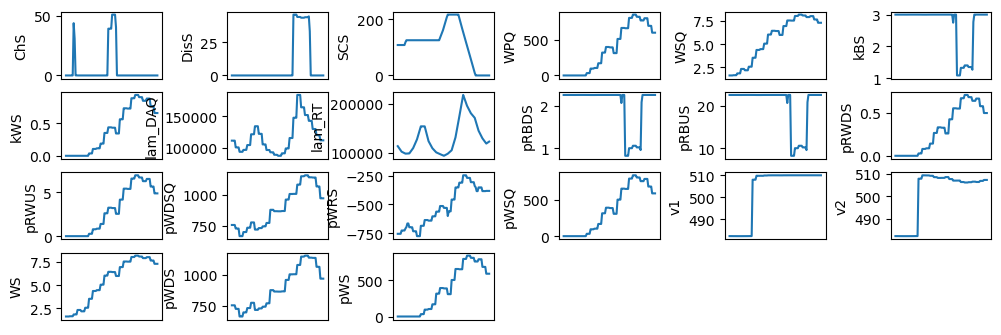

In [180]:
df = df_control.loc['CCD18_3_cotwdpge', 22]

s = 1
ncols, nrows = best_dims(len(df.columns))

plt.figure(figsize=(s*ar*ncols, s*nrows))

for i, c in enumerate(df):    
    df[c].plot(ax=plt.subplot(nrows, ncols, i + 1))
    plt.ylabel(c)
    plt.xlabel(None)
    plt.xticks([], [])
plt.subplots_adjust(wspace=.65)